# 1. Persiapan

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

nama_file = "/content/gta_v/gta_v_worldwide_sales_player_analytics_2013_2026.csv" # saya bikin di colab
df = pd.read_csv(nama_file)

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 14780 entries, 0 to 14779
Data columns (total 47 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   transaction_id                   14780 non-null  object 
 1   year                             14780 non-null  int64  
 2   month                            14780 non-null  int64  
 3   quarter                          14780 non-null  int64  
 4   country                          14780 non-null  object 
 5   iso3_code                        14780 non-null  object 
 6   region                           14780 non-null  object 
 7   platform                         14780 non-null  object 
 8   game_edition                     14780 non-null  object 
 9   sales_channel                    14780 non-null  object 
 10  retailer                         14780 non-null  object 
 11  units_sold                       14780 non-null  int64  
 12  gross_revenue_usd 

# 2. Menjawab Pertanyaan

### 1. Negara mana yang membeli produk terbanyak?

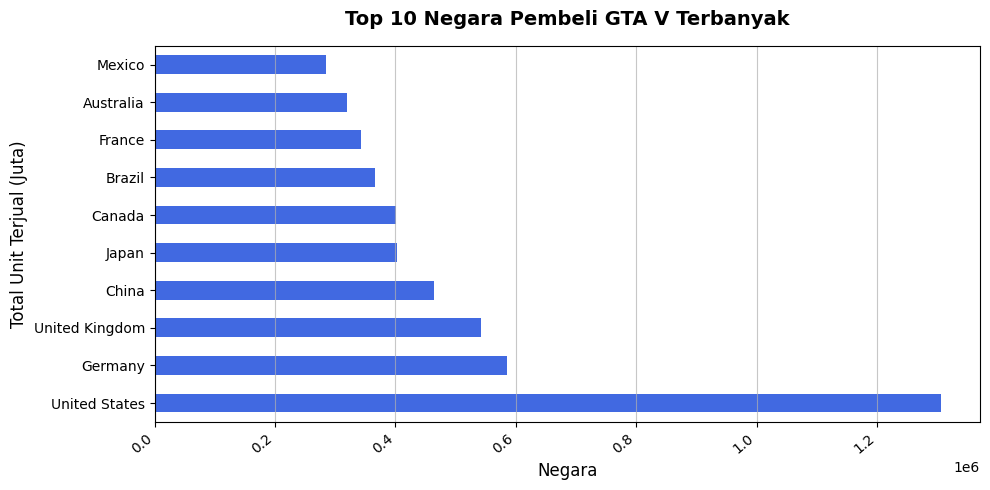

In [69]:
(
    df.groupby('country')['units_sold']
    .sum()
    .sort_values(ascending=False)
    .head(10)
    .plot(kind='barh', color='royalblue', figsize=(10, 5))
)

plt.title('Top 10 Negara Pembeli GTA V Terbanyak', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Negara', fontsize=12)
plt.ylabel('Total Unit Terjual (Juta)', fontsize=12)
plt.xticks(rotation=40, ha='right')
plt.grid(axis='x', linestyle='-', alpha=0.7)

plt.tight_layout()
plt.show()

### 2. Platform apa yang paling sering dipakai oleh gamers untuk memainkan GTA V?

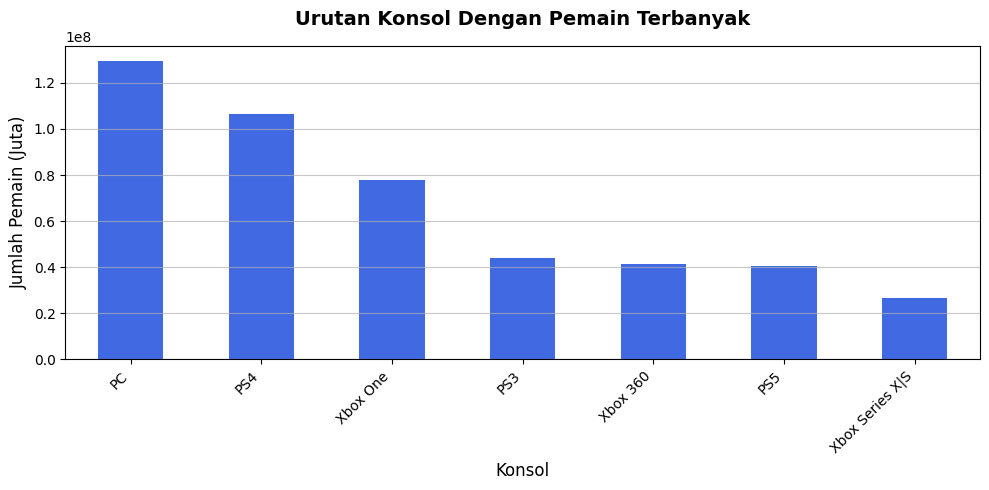

In [68]:
(
    df.groupby('platform')['estimated_active_players']
    .sum()
    .sort_values(ascending=False)
    .plot(kind='bar', color='royalblue', figsize=(10, 5))
)

plt.title('Urutan Konsol Dengan Pemain Terbanyak', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Konsol', fontsize=12)
plt.ylabel('Jumlah Pemain (Juta)', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', linestyle='-', alpha=0.7)

plt.tight_layout()
plt.show()

### 3. Apakah pendapatan dari Shark Cards lebih besar daripada pendapatan dari penjualan unit game dasar di negara-negara tertentu?"

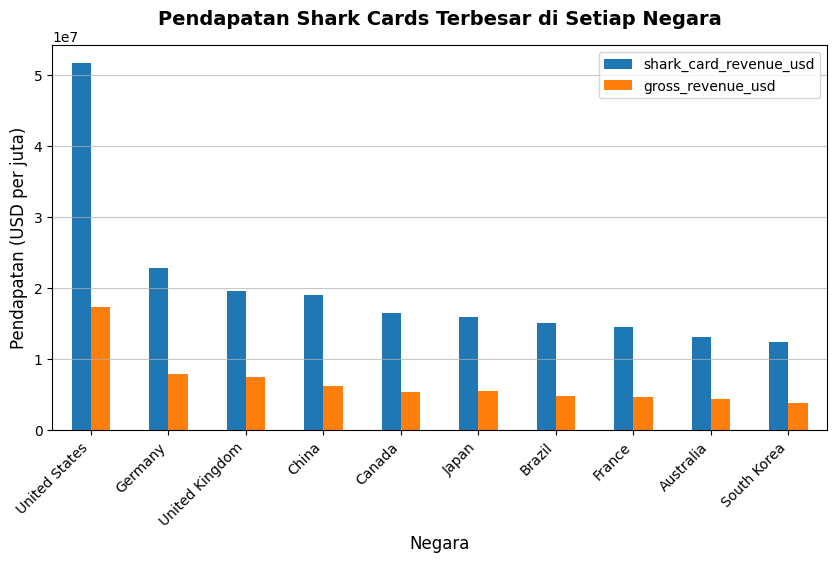

In [67]:
(
    df.groupby('country')[['shark_card_revenue_usd', 'gross_revenue_usd']]
    .sum()
    .sort_values(by='shark_card_revenue_usd', ascending=False)
    .head(10)
    .plot(kind='bar', figsize=(10, 5))
)

plt.title('Pendapatan Shark Cards Terbesar di Setiap Negara', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Negara', fontsize=12)
plt.ylabel('Pendapatan (USD per juta)', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', linestyle='-', alpha=0.7)

### 4. Estimasi Player Online vs Storymode dari Tahun ke-Tahun

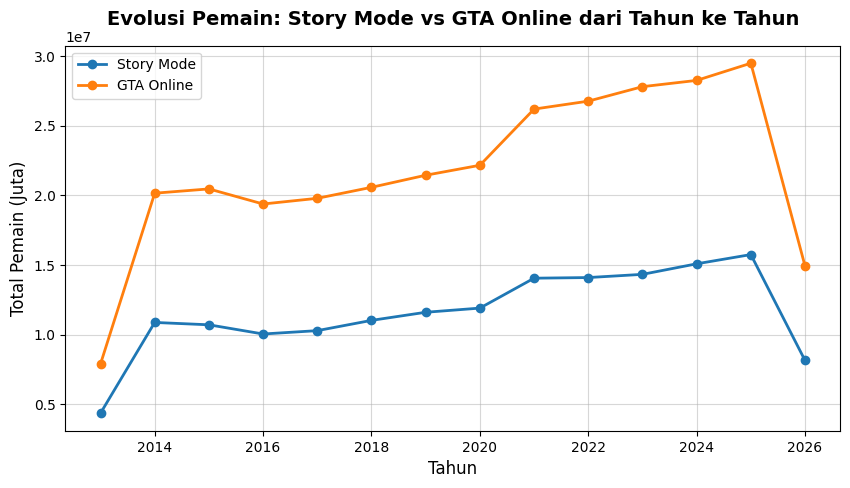

In [66]:
(
    df.groupby('year')[['story_mode_players', 'gta_online_players']]
    .sum()
    .plot(kind='line', marker='o', linewidth=2, figsize=(10, 5))
)

plt.title('Evolusi Pemain: Story Mode vs GTA Online dari Tahun ke Tahun', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Tahun', fontsize=12)
plt.ylabel('Total Pemain (Juta)', fontsize=12)
plt.grid(True, linestyle='-', alpha=0.5)
plt.legend(['Story Mode', 'GTA Online'])